# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [144]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0,)
]

In [145]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

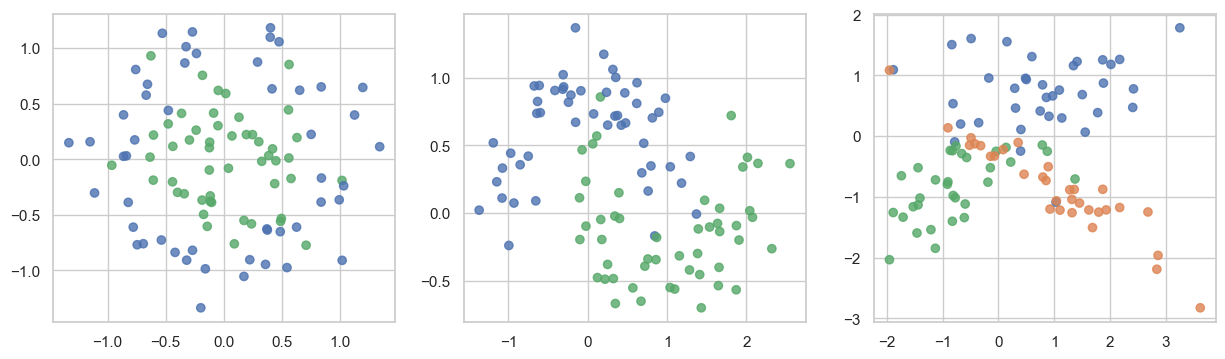

In [146]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [147]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

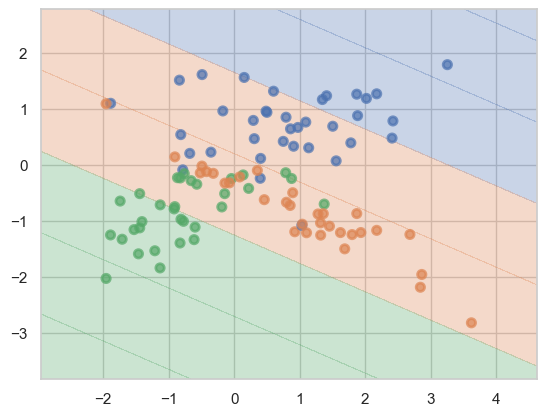

In [148]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Dataset: Circles
Train Accuracy: 1.00
Test Accuracy: 0.73
Overfit: 0.27

Dataset: Moons
Train Accuracy: 1.00
Test Accuracy: 0.87
Overfit: 0.13

Dataset: Classification
Train Accuracy: 1.00
Test Accuracy: 0.83
Overfit: 0.17



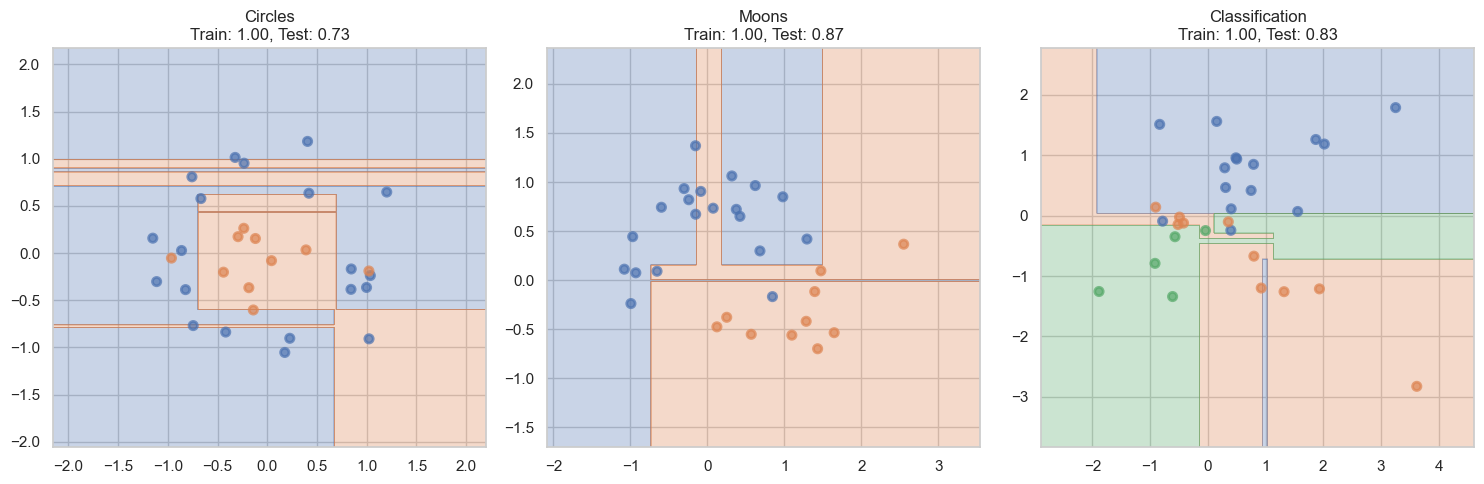

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dataset_names = ['Circles', 'Moons', 'Classification']

plt.figure(figsize=(15, 5))

for i, (X, y) in enumerate(datasets):
    # разбиваем на  train и test 30 % под тестирование и 70 % под обучение seed возьмем равный 42 по стандарту и как было взято выше
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # обучаем дерево
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    # делаем прогноз
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"Dataset: {dataset_names[i]}")
    print(f"Train Accuracy: {train_acc:.2f}")
    print(f"Test Accuracy: {test_acc:.2f}")
    print(f"Overfit: {train_acc - test_acc:.2f}\n")

    plt.subplot(1, 3, i + 1)
    plot_surface(model, X_test, y_test)
    plt.title(f"{dataset_names[i]}\nTrain: {train_acc:.2f}, Test: {test_acc:.2f}")

plt.tight_layout()
plt.show()

## Вывод по зад №1

**Деревья решений сильно переобучились** , потому что по умолчанию они не имеют ограничений на глубину и размер листьев. Из-за этого дерево "запоминает" обучающие данные, идеально справляясь с ними (train accuracy = 1.0), но теряет способность обобщать на новые данные (test accuracy). Это видно по большой разнице между train и test точностью, а также по сложной, фрагментированной разделяющей поверхности. Чтобы уменьшить переобучение, нужно регулировать сложность дерева через гиперпараметры, такие как max_depth и min_samples_leaf.

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?


----------------------------------------
Датасет: Circles
----------------------------------------
max_depth=1, min_samples_leaf=1 | Train: 0.73, Test: 0.47, Overfit: 0.26
max_depth=1, min_samples_leaf=5 | Train: 0.73, Test: 0.47, Overfit: 0.26
max_depth=1, min_samples_leaf=10 | Train: 0.73, Test: 0.47, Overfit: 0.26
max_depth=3, min_samples_leaf=1 | Train: 0.89, Test: 0.73, Overfit: 0.15
max_depth=3, min_samples_leaf=5 | Train: 0.86, Test: 0.80, Overfit: 0.06
max_depth=3, min_samples_leaf=10 | Train: 0.81, Test: 0.77, Overfit: 0.05
max_depth=5, min_samples_leaf=1 | Train: 0.97, Test: 0.77, Overfit: 0.20
max_depth=5, min_samples_leaf=5 | Train: 0.87, Test: 0.90, Overfit: -0.03
max_depth=5, min_samples_leaf=10 | Train: 0.81, Test: 0.77, Overfit: 0.05
max_depth=7, min_samples_leaf=1 | Train: 1.00, Test: 0.73, Overfit: 0.27
max_depth=7, min_samples_leaf=5 | Train: 0.87, Test: 0.90, Overfit: -0.03
max_depth=7, min_samples_leaf=10 | Train: 0.81, Test: 0.77, Overfit: 0.05


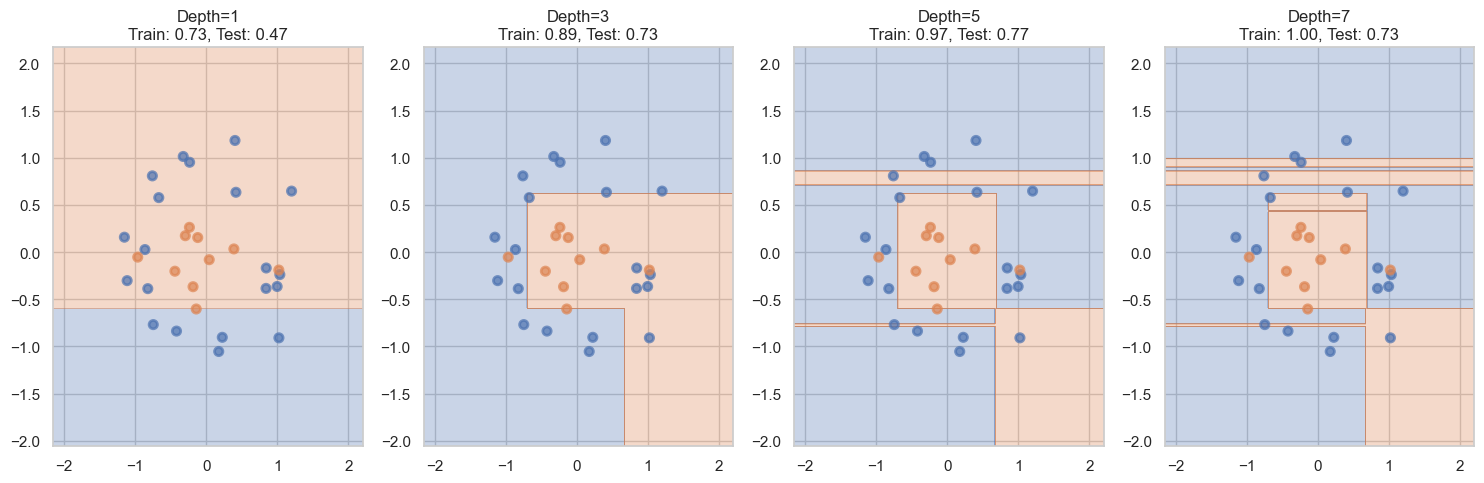


----------------------------------------
Датасет: Moons
----------------------------------------
max_depth=1, min_samples_leaf=1 | Train: 0.84, Test: 0.80, Overfit: 0.04
max_depth=1, min_samples_leaf=5 | Train: 0.84, Test: 0.80, Overfit: 0.04
max_depth=1, min_samples_leaf=10 | Train: 0.84, Test: 0.80, Overfit: 0.04
max_depth=3, min_samples_leaf=1 | Train: 0.91, Test: 0.93, Overfit: -0.02
max_depth=3, min_samples_leaf=5 | Train: 0.89, Test: 0.80, Overfit: 0.09
max_depth=3, min_samples_leaf=10 | Train: 0.87, Test: 0.77, Overfit: 0.10
max_depth=5, min_samples_leaf=1 | Train: 1.00, Test: 0.87, Overfit: 0.13
max_depth=5, min_samples_leaf=5 | Train: 0.96, Test: 0.73, Overfit: 0.22
max_depth=5, min_samples_leaf=10 | Train: 0.87, Test: 0.77, Overfit: 0.10
max_depth=7, min_samples_leaf=1 | Train: 1.00, Test: 0.87, Overfit: 0.13
max_depth=7, min_samples_leaf=5 | Train: 0.96, Test: 0.73, Overfit: 0.22
max_depth=7, min_samples_leaf=10 | Train: 0.87, Test: 0.77, Overfit: 0.10


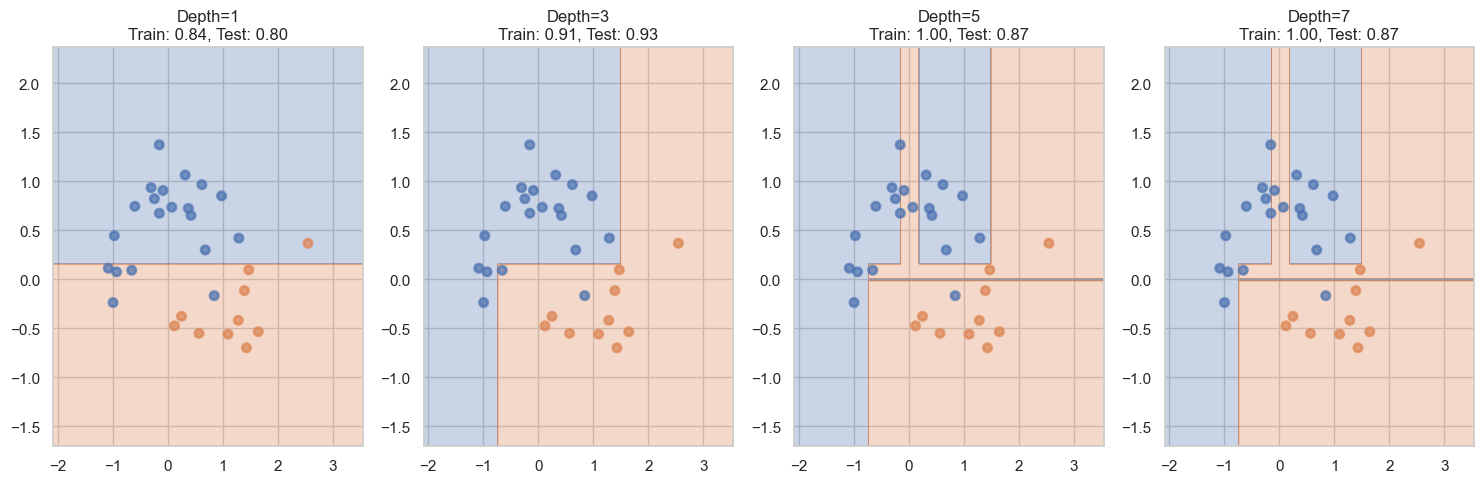


----------------------------------------
Датасет: Classification
----------------------------------------
max_depth=1, min_samples_leaf=1 | Train: 0.67, Test: 0.60, Overfit: 0.07
max_depth=1, min_samples_leaf=5 | Train: 0.67, Test: 0.60, Overfit: 0.07
max_depth=1, min_samples_leaf=10 | Train: 0.67, Test: 0.60, Overfit: 0.07
max_depth=3, min_samples_leaf=1 | Train: 0.94, Test: 0.87, Overfit: 0.08
max_depth=3, min_samples_leaf=5 | Train: 0.89, Test: 0.77, Overfit: 0.12
max_depth=3, min_samples_leaf=10 | Train: 0.89, Test: 0.77, Overfit: 0.12
max_depth=5, min_samples_leaf=1 | Train: 0.97, Test: 0.80, Overfit: 0.17
max_depth=5, min_samples_leaf=5 | Train: 0.90, Test: 0.70, Overfit: 0.20
max_depth=5, min_samples_leaf=10 | Train: 0.89, Test: 0.77, Overfit: 0.12
max_depth=7, min_samples_leaf=1 | Train: 1.00, Test: 0.83, Overfit: 0.17
max_depth=7, min_samples_leaf=5 | Train: 0.90, Test: 0.70, Overfit: 0.20
max_depth=7, min_samples_leaf=10 | Train: 0.89, Test: 0.77, Overfit: 0.12


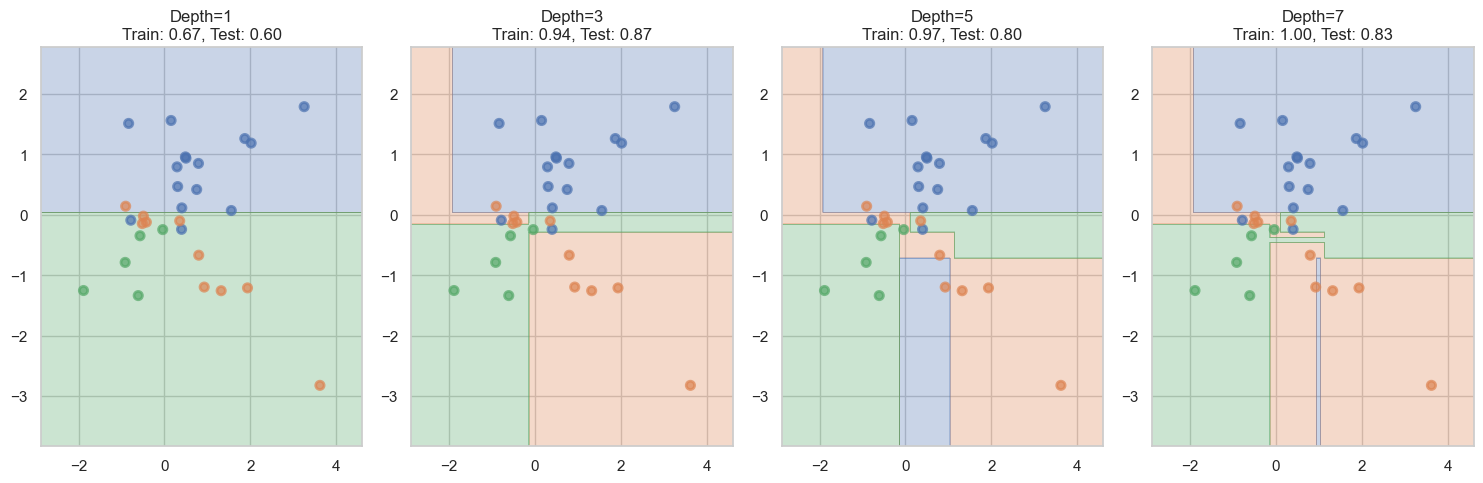

In [150]:
params_grid = {
    'max_depth': [1, 3, 5, 7], # когда маленькая глубина → простое дерево, большая → сложное, склонное к переобучению
    'min_samples_leaf': [1, 5, 10] # минимальное число образцов в листовом узле. при увел. этого параметра уменьшается переобучение
}


for idx, (X, y) in enumerate(datasets):
    print(f"\n{'-'*40}\nДатасет: {dataset_names[idx]}\n{'-'*40}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    plt.figure(figsize=(15, 5))
    plot_num = 1
    
    for max_depth in params_grid['max_depth']:
        for min_samples_leaf in params_grid['min_samples_leaf']:
            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            )
            model.fit(X_train, y_train)
            
            train_acc = accuracy_score(y_train, model.predict(X_train))
            test_acc = accuracy_score(y_test, model.predict(X_test))
            
            print(f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf} | "
                  f"Train: {train_acc:.2f}, Test: {test_acc:.2f}, Overfit: {train_acc - test_acc:.2f}")

            if min_samples_leaf == 1:
                plt.subplot(1, len(params_grid['max_depth']), plot_num)
                plot_surface(model, X_test, y_test)
                plt.title(f"Depth={max_depth}\nTrain: {train_acc:.2f}, Test: {test_acc:.2f}")
                plot_num += 1

    plt.tight_layout()
    plt.show()

## Вывод по зад №2

Можно заметить что решающие деревья склонны к переобучению при увеличении глубины и отсутствии регуляризации, особенно на сложных структурах данных. На всех датасетах при максимальной глубине и минимальном числе образцов в листе модель идеально воспроизводит обучающую выборку, но теряет точность на тестовых данных. Увеличение параметра min_samples_leaf снижает переобучение, особенно эффективно для датасетов Circles и Moons, где при значениях 5–10 достигается баланс между точностью и обобщающей способностью. Для датасета Moons оптимальные гиперпараметры позволили тестовой точности превысить обучающую, демонстрируя устойчивость модели. В случае Classification переобучение проявлялось наиболее выраженно, требуя строгой регуляризации. Лучшие результаты достигались при средних значениях max_depth (3–5) и min_samples_leaf (от 5).

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

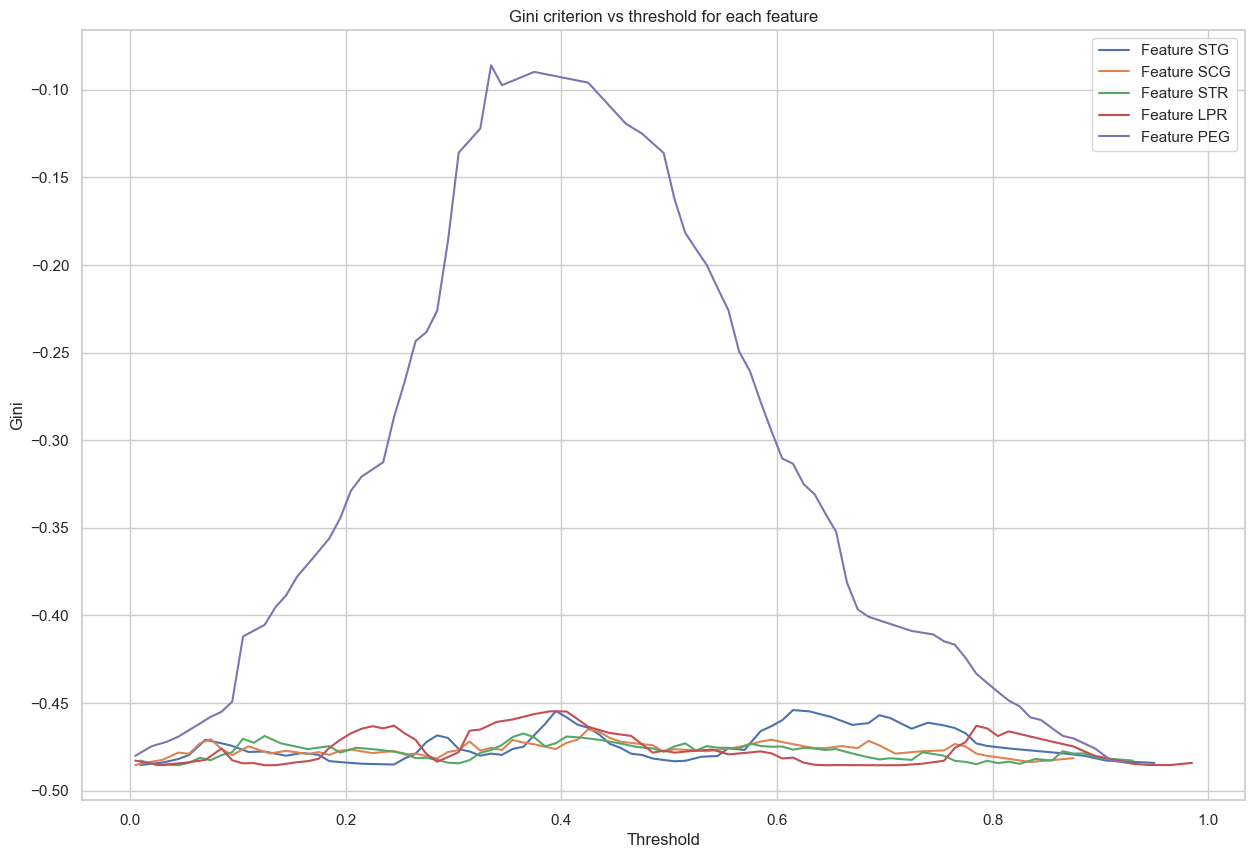

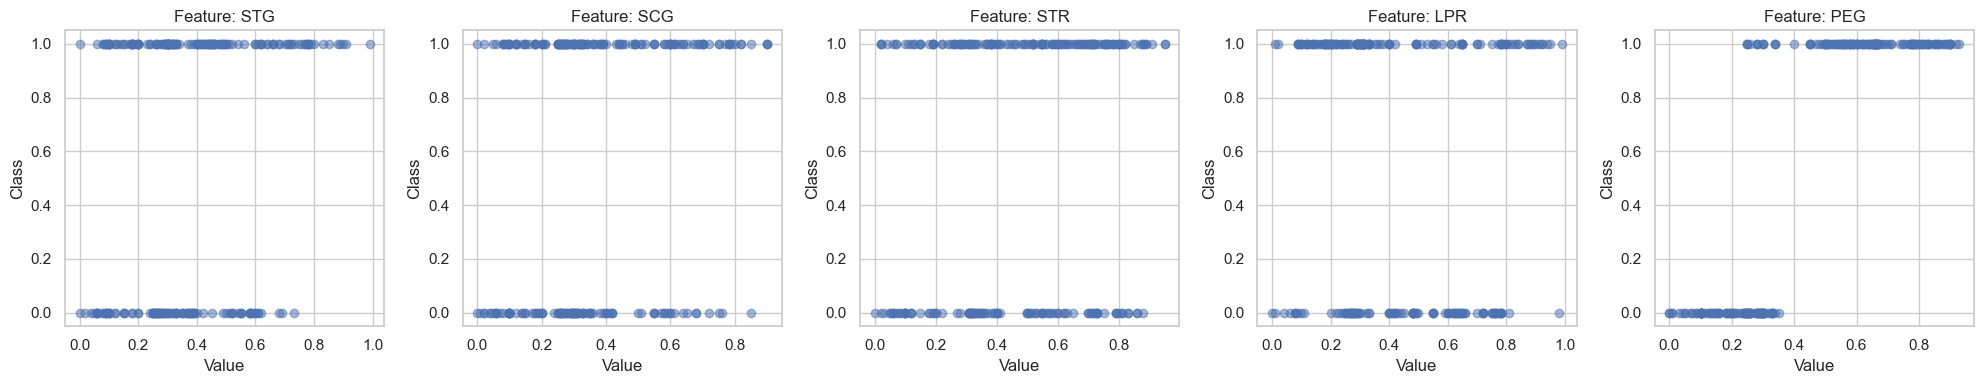

In [151]:

from hw2code import find_best_split

df = pd.read_csv("datasets/students.csv")
X = df.iloc[:, :-1]
y = df.iloc[:, -1].values

plt.figure(figsize=(15, 10))

for i, column in enumerate(X.columns):
    thresholds, ginis, _, _ = find_best_split(X[column].values, y)
    plt.plot(thresholds, ginis, label=f'Feature {column}')

plt.title("Gini criterion vs threshold for each feature")
plt.xlabel("Threshold")
plt.ylabel("Gini")
plt.legend()
plt.grid(True)
plt.show()

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, column in enumerate(X.columns):
    axs[i].scatter(X[column], y, alpha=0.5)
    axs[i].set_title(f'Feature: {column}')
    axs[i].set_xlabel("Value")
    axs[i].set_ylabel("Class")

plt.tight_layout()
plt.show()


__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

## Ответ:

Признак PEG является наилучшим для разбиения выборки, так как его кривая критерия Джини показывает резкое улучшение разделения классов при определённом пороге. Это полностью согласуется с scatter-графиком, где классы почти идеально разделены по этому признаку. У хороших признаков кривая Джини имеет ярко выраженный минимум, указывающий на чёткий порог разделения, тогда как у плохих признаков кривая почти плоская и не показывает значимого улучшения при любом пороге.










__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [153]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

import hw2code
import importlib
importlib.reload(hw2code)

df = pd.read_csv("datasets/agaricus-lepiota.data", header=None)

label_encoders = defaultdict(LabelEncoder)
features_encoded = df.apply(lambda col: label_encoders[col.name].fit_transform(col))

target_col = features_encoded.iloc[:, 0]
other_features = features_encoded.iloc[:, 1:]

unique_values = target_col.unique()
if len(unique_values) > 2:
    raise ValueError("Поддерживается только бинарная классификация")

class_to_index = {val: idx for idx, val in enumerate(unique_values)}
y_binary = target_col.map(class_to_index).values

X = other_features.values

feature_types = ["categorical"] * X.shape[1]

X_train, X_val, y_train, y_val = train_test_split(X, y_binary, test_size=0.5, random_state=42)

clf = hw2code.DecisionTree(
    feature_types=feature_types,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1
)
clf.fit(X_train, y_train)

# Предсказание и оценка
preds = clf.predict(X_val)
acc = accuracy_score(y_val, preds)
tree_depth = clf.get_depth()

print(f"\nМетрика точности на тестовой выборке: {acc:.4f}")
print(f'Глубина построенного решающего дерева: {tree_depth}')



Метрика точности на тестовой выборке: 1.0000
Глубина построенного решающего дерева: 7


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [154]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split


datasets = {
    "mushrooms":    "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data",
    "tic_tac_toe":  "https://archive.ics.uci.edu/ml/machine-learning-databases/tic-tac-toe/tic-tac-toe.data",
    "cars":         "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data",
    "nursery":      "https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data"
}

results_list = []

for ds_name, url in datasets.items():
    df = pd.read_csv(url, header=None)
    
    if ds_name == "mushrooms":
        X_df = df.iloc[:, 1:].copy()
        y_ser = df.iloc[:, 0].map({'e':1, 'p':0})
    elif ds_name == "tic_tac_toe":
        X_df = df.iloc[:, :-1].copy()
        y_ser = df.iloc[:, -1].map({'negative':0, 'positive':1})
    elif ds_name == "cars":
        X_df = df.iloc[:, :-1].copy()
        y_ser = df.iloc[:, -1].map({'unacc':0, 'acc':0, 'good':1, 'vgood':1})
    elif ds_name == "nursery":
        X_df = df.iloc[:, :-1].copy()
        y_ser = df.iloc[:, -1].map({'not_recom':0, 'recommend':0,
                                     'very_recom':1, 'priority':1, 'spec_prior':1})
    else:
        continue
    
    X_cat = X_df.values   # для «категориального» режима
    y = y_ser.values      # целевой вектор

    # 3) собираем «numeric» (LabelEncoder→int) и «one-hot» представления:
    X_num = np.zeros_like(X_cat, dtype=float)
    for col in range(X_cat.shape[1]):
        le = LabelEncoder()
        X_num[:, col] = le.fit_transform(X_cat[:, col])
    
    ohe = OneHotEncoder(sparse_output=False)
    X_onehot = ohe.fit_transform(X_cat)

    # 4) Кросс-валидация (KFold с 10 фолдами)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    acc_dt_real       = []
    acc_dt_cat        = []
    acc_dt_onehot     = []
    acc_sklearn_dt    = []
    
    for train_idx, test_idx in kf.split(X_cat):
        Xtr_cat = X_cat[train_idx]
        Xte_cat = X_cat[test_idx]
        
        Xtr_num = X_num[train_idx]
        Xte_num = X_num[test_idx]
        
        Xtr_ohe = X_onehot[train_idx]
        Xte_ohe = X_onehot[test_idx]
        
        ytr = y[train_idx]
        yte = y[test_idx]
        
        # (все признаки «вещественные») 
        dt_real = DecisionTree(feature_types=['real'] * X_num.shape[1])
        dt_real.fit(Xtr_num, ytr)
        ypred = dt_real.predict(Xte_num)
        acc_dt_real.append(accuracy_score(yte, ypred))
        
        #  DecisionTree (все признаки «категориальные») 
        dt_cat = DecisionTree(feature_types=['categorical'] * X_cat.shape[1])
        dt_cat.fit(Xtr_cat, ytr)
        ypred = dt_cat.predict(Xte_cat)
        acc_dt_cat.append(accuracy_score(yte, ypred))
        
        # (one-hot → «вещественные») 
        dt_ohe = DecisionTree(feature_types=['real'] * X_onehot.shape[1])
        dt_ohe.fit(Xtr_ohe, ytr)
        ypred = dt_ohe.predict(Xte_ohe)
        acc_dt_onehot.append(accuracy_score(yte, ypred))
        
        # (one-hot) 
        sk_dt = DecisionTreeClassifier()
        sk_dt.fit(Xtr_ohe, ytr)
        ypred = sk_dt.predict(Xte_ohe)
        acc_sklearn_dt.append(accuracy_score(yte, ypred))
    
    # усредняем по фолдам
    results_list.append({
        'dataset':           ds_name,
        'DT_real':          np.mean(acc_dt_real),
        'DT_cat':           np.mean(acc_dt_cat),
        'DT_real_onehot':   np.mean(acc_dt_onehot),
        'SKlearn_DT':       np.mean(acc_sklearn_dt)
    })

results_df = pd.DataFrame(results_list).set_index('dataset')
print(results_df)

              DT_real    DT_cat  DT_real_onehot  SKlearn_DT
dataset                                                    
mushrooms    1.000000  1.000000        1.000000    1.000000
tic_tac_toe  0.841338  0.886184        0.942632    0.953048
cars         0.975675  0.965268        0.987851    0.988426
nursery      0.999769  0.999769        0.999769    0.999769


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**

Вставьте что угодно, описывающее ваши впечатления от этого задания:

Результаты показывают, что всё зависит от набора данных. Например, на mushrooms все алгоритмы показывают 100% точность — скорее всего, потому что признаки там очень сильные и легко разделяют классы. А вот на других датасетах, например tic_tac_toe или cars, уже видно, что способ кодирования влияет на итог — one-hot даёт заметный прирост точности.

Также видно, что в результатах есть некоторая случайность — из-за разбиения в кросс-валидации результаты могут немного меняться. Это можно контролировать с помощью random_state. Ну и понятно, что если использовать более сложные методы кодирования и подбирать параметры, то можно ещё улучшить точность.